# ***Student Name: Tushar Panchal***

# ***En. No. : 21162101014***

# ***Branch: CBA***

# ***Batch:  71***

# ***Subject: ML (Machine Learning)***

# **EXPERIMENT 7**
###**Aim - Clustering of mall customers**

- For a given dataset make clusters of customers using different attributes.
- Change values of hyper parameters in each model i.e value of k in k-means and select the best value
- Plot graph of clusters with centroid for each model


**Use following models :**
- k-means
- Fuzzy c mean :  Plot graph of clusters generated by fuzzy c mean
- DBSCAN

**Calculate silhouette score, db index and dunn index for all three models and write your conclusion based on it**


In [ ]:
!pip install -q scikit-fuzzy
!pip install tabulate

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform
import skfuzzy as fuzz
from tabulate import tabulate

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_7/p7_mallcstmrsMall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop CustomerID as it's irrelevant for clustering
df = df.drop(['CustomerID'], axis=1)

# Encode the categorical column 'Genre' (Male=1, Female=0)
df['Genre'] = df['Genre'].map({'Male': 1, 'Female': 0})

# Feature Scaling (standardizing the data)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print()
print(df_scaled[:5])

Missing values in each column:
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

[[ 1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [ 1.12815215 -1.28103541 -1.73899919  1.19570407]
 [-0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [-0.88640526 -1.13750203 -1.70082976  1.04041783]
 [-0.88640526 -0.56336851 -1.66266033 -0.39597992]]


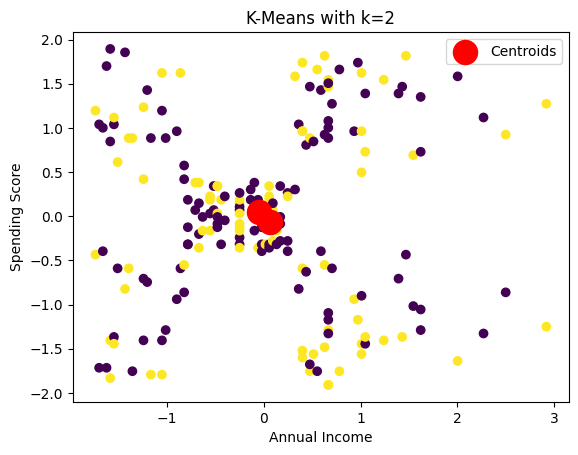

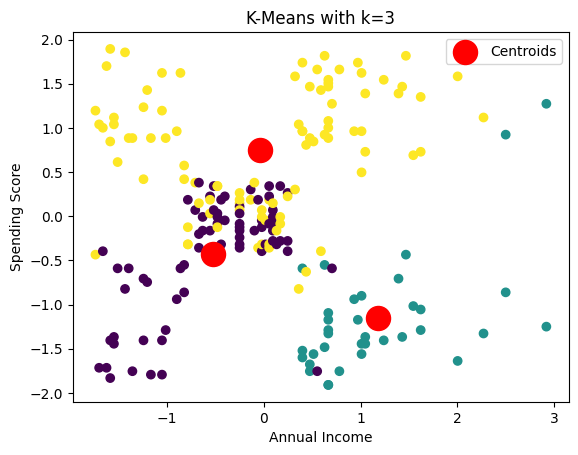

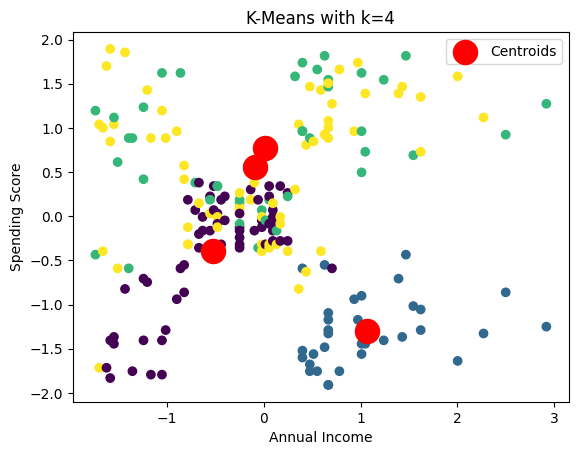

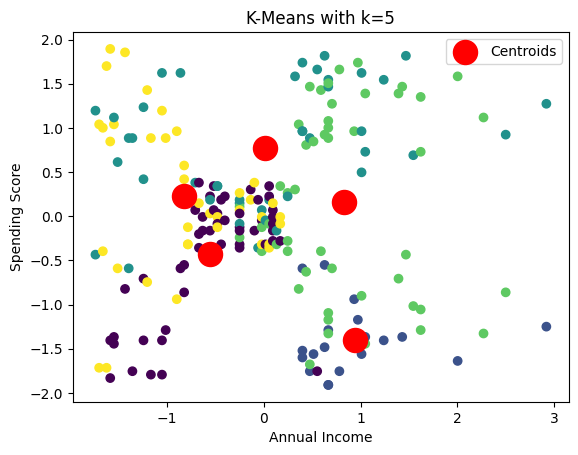

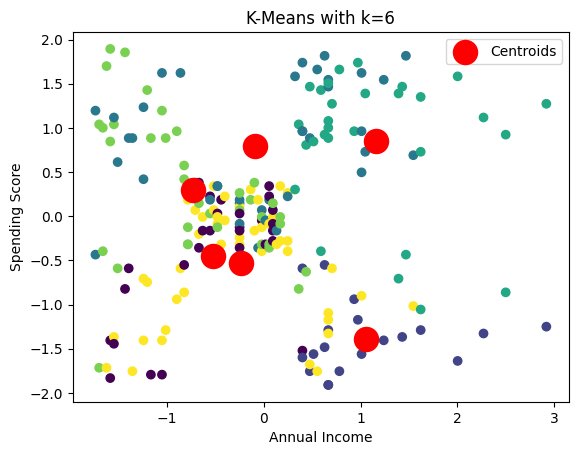

Silhouette Scores: [0.2776035125578272, 0.2576199805135528, 0.29010917402310876, 0.27191023466188324, 0.3347543475669217]
Davies-Bouldin Scores: [1.6116938570457684, 1.4248671516594265, 1.3055634908016425, 1.181091452406171, 1.0139617115807866]


In [ ]:
# List to store evaluation metrics
silhouette_scores = []
davies_bouldin_scores = []

# Try different values of k (number of clusters)
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_scaled)

    # Calculate silhouette score and Davies-Bouldin index
    silhouette = silhouette_score(df_scaled, cluster_labels)
    db_index = davies_bouldin_score(df_scaled, cluster_labels)

    silhouette_scores.append(silhouette)
    davies_bouldin_scores.append(db_index)

    # Plot the clusters
    plt.figure()
    plt.scatter(df_scaled[:, 2], df_scaled[:, 3], c=cluster_labels, cmap='viridis')
    plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 3], s=300, c='red', label='Centroids')
    plt.title(f'K-Means with k={k}')
    plt.xlabel('Annual Income')
    plt.ylabel('Spending Score')
    plt.legend()
    plt.show()

# Print the silhouette and Davies-Bouldin scores
print("Silhouette Scores:", silhouette_scores)
print("Davies-Bouldin Scores:", davies_bouldin_scores)

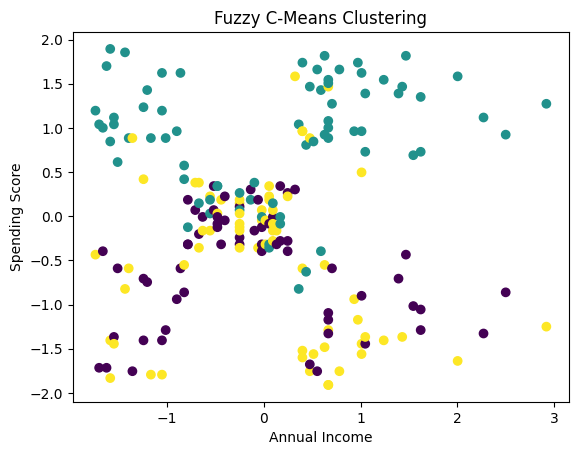

In [ ]:
# Fuzzy C-Means clustering
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(df_scaled.T, 3, 2, error=0.005, maxiter=1000, init=None)

# Assign each data point to the cluster with the highest membership degree
cluster_labels_fcm = np.argmax(u, axis=0)

# Plot Fuzzy C-Means clusters
plt.scatter(df_scaled[:, 2], df_scaled[:, 3], c=cluster_labels_fcm, cmap='viridis')
plt.title('Fuzzy C-Means Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

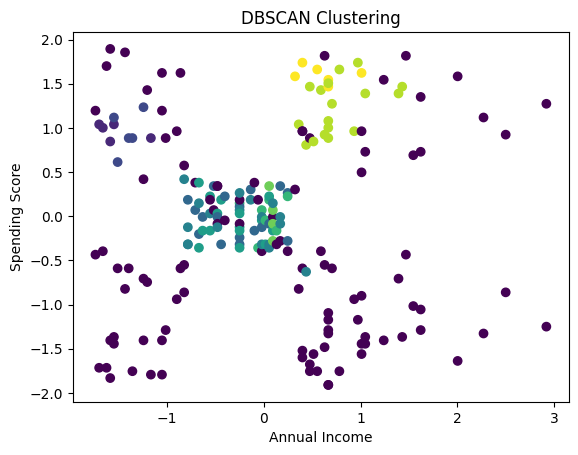

In [ ]:
# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
cluster_labels_dbscan = dbscan.fit_predict(df_scaled)

# Plot DBSCAN clusters
plt.scatter(df_scaled[:, 2], df_scaled[:, 3], c=cluster_labels_dbscan, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

In [ ]:
# Function to calculate Dunn Index
def dunn_index(X, labels):
    distances = squareform(pdist(X))
    unique_clusters = np.unique(labels)
    intra_dists = []
    min_inter_dists = np.inf

    for cluster in unique_clusters:
        intra_dists.append(np.mean(distances[labels == cluster][:, labels == cluster]))

    for i in range(len(unique_clusters)):
        for j in range(i + 1, len(unique_clusters)):
            inter_dist = np.min(distances[labels == unique_clusters[i]][:, labels == unique_clusters[j]])
            if inter_dist < min_inter_dists:
                min_inter_dists = inter_dist

    return min_inter_dists / np.max(intra_dists)

# Calculate metrics for K-Means
silhouette_kmeans = silhouette_score(df_scaled, cluster_labels)
db_index_kmeans = davies_bouldin_score(df_scaled, cluster_labels)
dunn_kmeans = dunn_index(df_scaled, cluster_labels)

# Calculate metrics for Fuzzy C-Means
silhouette_fcm = silhouette_score(df_scaled, cluster_labels_fcm)
db_index_fcm = davies_bouldin_score(df_scaled, cluster_labels_fcm)
dunn_fcm = dunn_index(df_scaled, cluster_labels_fcm)

# Calculate metrics for DBSCAN
silhouette_dbscan = silhouette_score(df_scaled, cluster_labels_dbscan)
db_index_dbscan = davies_bouldin_score(df_scaled, cluster_labels_dbscan)
dunn_dbscan = dunn_index(df_scaled, cluster_labels_dbscan)

evaluation_data = [
    ['K-Means', round(silhouette_kmeans, 2), round(db_index_kmeans, 2), round(dunn_kmeans, 2)],
    ['Fuzzy C-Means', round(silhouette_fcm, 2), round(db_index_fcm, 2), round(dunn_fcm, 2)],
    ['DBSCAN', round(silhouette_dbscan, 2), round(db_index_dbscan, 2), round(dunn_dbscan, 2)]
]

headers = ['Model', 'Silhouette Score', 'DB Index', 'Dunn Index']

print(tabulate(evaluation_data, headers=headers, tablefmt='fancy_grid'))


╒═══════════════╤════════════════════╤════════════╤══════════════╕
│ Model         │   Silhouette Score │   DB Index │   Dunn Index │
╞═══════════════╪════════════════════╪════════════╪══════════════╡
│ K-Means       │               0.33 │       1.01 │         0.22 │
├───────────────┼────────────────────┼────────────┼──────────────┤
│ Fuzzy C-Means │               0.23 │       1.38 │         0.09 │
├───────────────┼────────────────────┼────────────┼──────────────┤
│ DBSCAN        │               0.01 │       1.39 │         0.08 │
╘═══════════════╧════════════════════╧════════════╧══════════════╛


In [ ]:
print("K-Means is the best model with the highest Silhouette Score (0.33), best DB Index (1.01), and higher Dunn Index (0.22).")
print("DBSCAN performed the worst, with the lowest Silhouette Score (0.01) and Dunn Index (0.08), and the highest DB Index (1.39).")

K-Means is the best model with the highest Silhouette Score (0.33), best DB Index (1.01), and higher Dunn Index (0.22).
DBSCAN performed the worst, with the lowest Silhouette Score (0.01) and Dunn Index (0.08), and the highest DB Index (1.39).
